In [32]:
import pandas as pd
import os
# Default values defined in the notebook for Station and OSVAS install:
OSVAS='/home/alvaro/master/TFM/OSVAS'  # Main OSVAS path
Station_name='Cabauw'

# If an environment variable STATION or OSVAS exists, override the default
Station_name = os.getenv("STATION_NAME", Station_name)
OSVAS = os.getenv("OSVAS", OSVAS)

key_path = os.path.join(OSVAS,"KMNI_token.txt")
api_key = open(key_path, "r").readline().strip()

start_date = pd.to_datetime('2017-01-01 00:00:00', utc=True)
end_date = pd.to_datetime('2020-12-31 23:59:59', utc=True)
print(f"Creating Validation files for: {Station_name} with OSVAS installation in {OSVAS}")

Creating Validation files for: Cabauw with OSVAS installation in /home/alvaro/master/TFM/OSVAS


In [2]:
# Necessary functions
from datetime import date, datetime, timedelta, timezone
from dateutil.relativedelta import relativedelta
from functools import reduce
import matplotlib
import matplotlib.pyplot as plt
from netCDF4 import Dataset, date2num
import numpy as np
import os
import pytz
import re
import requests
import sqlite3
import tempfile
import xarray as xr
import xml.etree.ElementTree as ET
import yaml

def download_file(endpoint, headers, filename, download_directory='./.nc_data'):
    """
        Downloads the file filename from the endpoint to download_directory. If open is set to true, 
        the function returns the opened Netcdf Dataset.

        Parameters:
            endpoint: The url of the endpoint to receive the list of files
            headers: Dictionary with request headers, Authentication is mandatory with the corresponding token.
            download_directory: The path to the directory where files will be downloaded.
    """
    result = requests.get('/'.join((endpoint, filename, 'url')), headers=headers)
    r = requests.get(result.json()['temporaryDownloadUrl'])
    r.raise_for_status()
    with tempfile.NamedTemporaryFile(suffix=".nc") as f:
        f.write(r.content)
        f.flush()
        ds = xr.open_dataset(f.name)  # or "h5netcdf"
    return ds

def fetch_file_list(endpoint, headers, payload):
    """
        File list returned by endpoint satisfying payload criteria.
        
        Parameters:
            endpoint: The url of the endpoint to receive the list of files
            headers: Dictionary with request headers, Authentication is mandatory with the corresponding token
            payload: Dictionary with optional parameters for the get request.
        
        return: A list with the filenames that satisfy the given criteria. This filenames can then be retrieved calling another KMNI API endpoint
        
    """
    file_list = []
    truncated = True
    while truncated:
        result = requests.get(endpoint, headers=headers, params=payload)
        result.raise_for_status()
        result = result.json()
        file_list += [i['filename'] for i in result['files']]
        truncated = result['isTruncated']
        if truncated:
            payload += {'nextPageToken': result['nextPageToken']}
    print(f"{len(file_list)} files will be processed")
    return file_list



def retrieve_data(endpoint, start_date, end_date, key):
    """
    Generates a dataset with the data collected from endpoint between start_date and end_date. It requires the api_key parameter 
    to make the requests to the service.
    """
    dataset_name = endpoint.split("/datasets/")[1].split("/")[0]
    dataset_version = endpoint.split("/versions/")[1].split("/")[0]
    start_file = (f"{dataset_name}_{dataset_version}_{start_date:%Y%m}.nc")
    end_file = (f"{dataset_name}_{dataset_version}_{end_date:%Y%m}.nc")
    months = pd.date_range(start=start_date, end=end_date, freq="MS")
    filenames = [f"{dataset_name}_{dataset_version}_{date:%Y%m}.nc" for date in months]
    headers={"Authorization": api_key}
    payload = {
        'maxKeys': '1000',
        'sorting': 'asc',
        'orderBy': 'filename',
        'begin': start_file,
        'end': end_file
    }
    file_list = fetch_file_list(endpoint, headers, payload)
    files = []
    for file in filenames:
        if file in file_list:
            files.append(download_file(endpoint, headers, file).drop_vars('valid_dates'))
        else:
            print(f"⚠️ {file} not found in KMNI service, data for this month will be filled with nan")
    ds_values = xr.concat(files, dim='time', data_vars='minimal').sortby('time')
    ds_values = ds_values.sel(time=slice(start_date.tz_localize(None), end_date.tz_localize(None)))
    #ds_values['SWD'] = ds_values['SWD'].clip(min=0)
    #ds_values['LWD'] = ds_values['SWD'].clip(min=0)
    return ds_values

In [37]:
# Temperatura y humedad, carga de datos:
doi = "https://api.dataplatform.knmi.nl/open-data/v1/datasets/cesar_soil_heat_lb1_t10/versions/v1.0/files"
temperature = retrieve_data(doi, start_date, end_date, api_key)

48 files will be processed


In [36]:
doi = "https://api.dataplatform.knmi.nl/open-data/v1/datasets/cesar_soil_water_lb1_t10/versions/v1.1/files"
moisture = retrieve_data(doi, start_date, end_date, api_key)

48 files will be processed


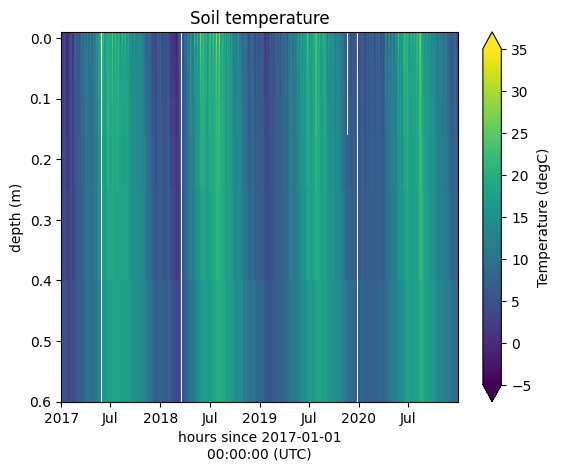

In [38]:
# Prepate temperature dataset (depth,time)
temperature = temperature[[v for v in temperature.data_vars if (v.startswith("TS")) and not (temperature[v].isnull().all())]]
depth = [int(v[2::])*.01 for v in temperature.data_vars]
temp = xr.concat([temperature[v] for v in temperature.data_vars], dim='depth').assign_coords(depth=depth)
temp.plot(cmap="viridis", cbar_kwargs={"label": "Temperature (degC)"}, extend='both', vmin=-5, vmax=35)
plt.title("Soil temperature")
plt.ylabel("depth (m)")
plt.gca().invert_yaxis()
plt.show()

In [ ]:
# Initialise using the X*_{SURF/ROOT/DEEP} fields
temp_surf = temp.sel(depth = temp.depth <= 0.05, time=temp.time[0]).mean('depth') + 273.15
temp_root = temp.sel(depth = temp.depth >= 0.05, time=temp.time[0]).mean('depth') + 273.15
temp_deep = temp.sel(depth = temp.depth[-1], time=temp.time[0]) + 273.15
print(temp_surf, temp_root, temp_deep)

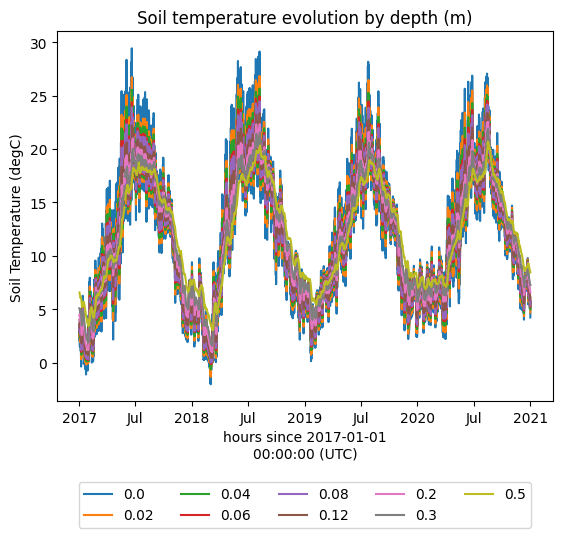

In [39]:
temp.plot.line(x = 'time', hue='depth')
ax = plt.gca()
ax.legend( 
    temp.depth.values, 
    ncol=5,                     # horizontal layout
    loc="upper center",
    bbox_to_anchor=(0.5, -0.2)
)
plt.title("Soil temperature evolution by depth (m)")
plt.ylabel("Soil Temperature (degC)")
plt.show()

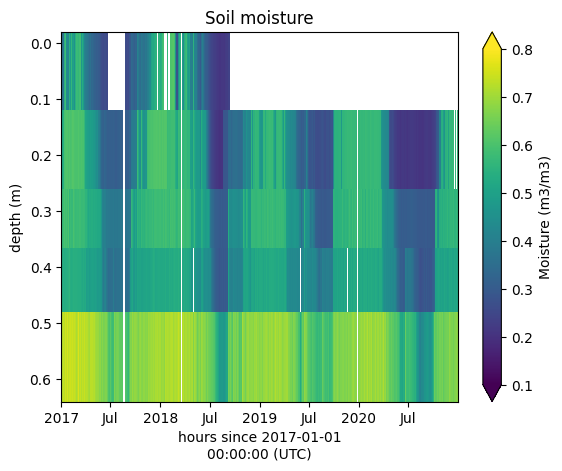

In [40]:
# Prepate temperature dataset (depth,time)
moisture = moisture[[v for v in moisture.data_vars if (v.startswith("TH")) and not (moisture[v].isnull().all())]]
depth = [int(v[2::])*.01 for v in moisture.data_vars]
swc = xr.concat([moisture[v] for v in moisture.data_vars], dim='depth').assign_coords(depth=depth)
swc.sel(depth = swc.depth != 0.03).plot(cmap="viridis", cbar_kwargs={"label": "Moisture (m3/m3)"}, vmin=0.1, vmax=.8, extend='both')
plt.title("Soil moisture")
plt.ylabel("depth (m)")
plt.gca().invert_yaxis()
plt.show()

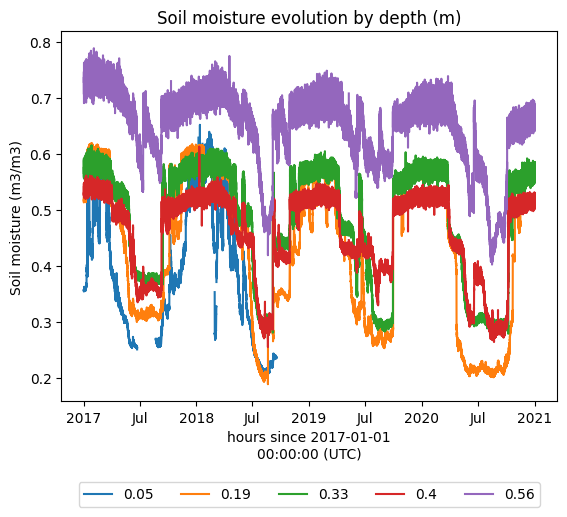

In [41]:
swc.sel(depth = swc.depth != 0.03).plot.line(x = 'time', hue="depth", add_legend=False)
ax = plt.gca()
ax.legend( 
    swc.depth.values[1::], 
    ncol=5,                     # horizontal layout
    loc="upper center",
    bbox_to_anchor=(0.5, -0.2)
)
plt.title("Soil moisture evolution by depth (m)")
plt.ylabel("Soil moisture (m3/m3)")
plt.show()

In [42]:
# Initialise using the X*_{SURF/ROOT/DEEP} fields
iswc_surf = (swc.sel(depth = swc.depth <= 0.05, time=swc.time[0]).mean('depth') - 0.253) /(0.468-0.253)
iswc_root = (swc.sel(depth = swc.depth >= 0.05, time=swc.time[0]).mean('depth') - 0.253) / (0.468-0.253)
iswc_deep = (swc.sel(depth = swc.depth[-1], time=swc.time[0]) - 0.253) / (0.468-0.253)
print(iswc_surf, iswc_root, iswc_deep)

<xarray.DataArray 'TH03' ()> Size: 8B
array(0.23850878)
Coordinates:
    time     datetime64[ns] 8B 2017-01-01
Attributes:
    units:         m3 m-3
    long_name:     Soil water content at 0.03 m depth Campbell calibration
    cell_methods:  time: mean <xarray.DataArray 'TH03' ()> Size: 8B
array(1.33235298)
Coordinates:
    time     datetime64[ns] 8B 2017-01-01
Attributes:
    units:         m3 m-3
    long_name:     Soil water content at 0.03 m depth Campbell calibration
    cell_methods:  time: mean <xarray.DataArray 'TH03' ()> Size: 4B
array(2.212519, dtype=float32)
Coordinates:
    time     datetime64[ns] 8B 2017-01-01
    depth    float64 8B 0.56
Attributes:
    units:         m3 m-3
    long_name:     Soil water content at 0.03 m depth Campbell calibration
    cell_methods:  time: mean


In [31]:
base = xr.open_dataset('../../RUNS/Cabauw/BASECABAUW/output/SURF_ATM_DIAGNOSTICS.OUT.nc', decode_times=False)
base['Q2M'] #Diagnostics variables T2M, Q2M, W10M

<xarray.DataArray 'Q2M' (time: 20447, lat: 1, lon: 1)> Size: 164kB
[20447 values with dtype=float64]
Coordinates:
  * time     (time) float64 164kB 30.0 60.0 90.0 ... 6.134e+05 6.134e+05
  * lat      (lat) float64 8B 51.98
  * lon      (lon) float64 8B 4.925
Attributes:
    long_name:     X_Y_Q2M
    units:         KG/KG
    grid_mapping:  Projection_Type

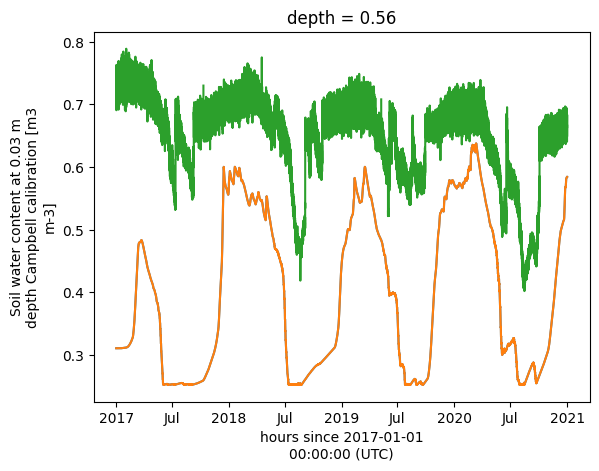

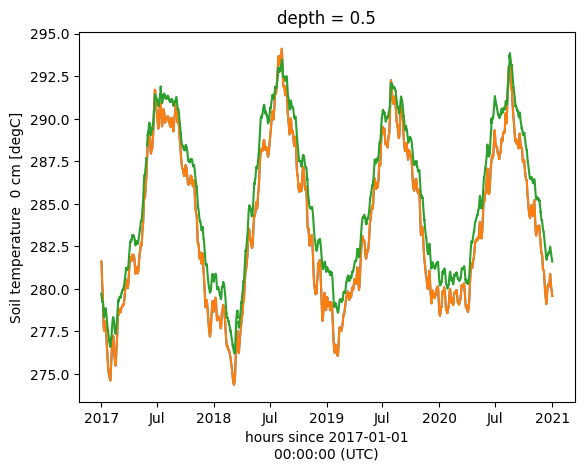

In [89]:
base_data['WG6_ISBA'].plot()
x_data['WG6_ISBA'].plot()
swc.sel(depth = .56).plot()

plt.show()

base_data['TG6_ISBA'].plot()
x_data['TG6_ISBA'].plot()
(temp.sel(depth = .5) + 273.15).plot()
plt.show()

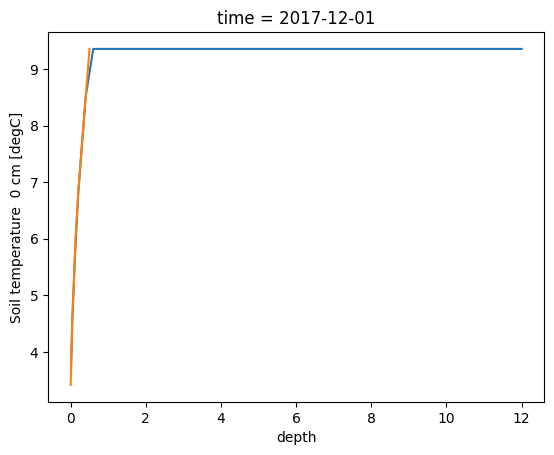

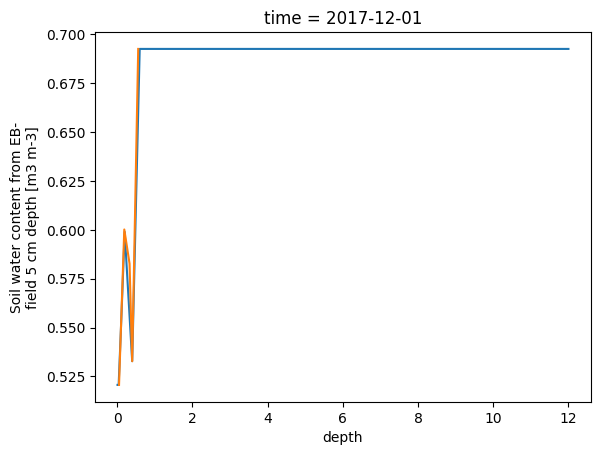

In [166]:
#Simple approach Linear interpolation + Constant outside the interval (just for initialization, not good for validation)
XSOILGRID = [0.01,0.04,0.10,0.20,0.40,0.60,0.80,1.00,1.50,2.00,3.00,5.00,8.00,12.0]
d_min = temp.depth.min()
d_max = temp.depth.max()
t_interp = temp.interp(depth=XSOILGRID, method = 'linear')
up_const = temp.sel(depth=d_min)
down_const = temp.sel(depth=d_max)
t_interp0 = t_interp.where(t_interp.depth <= d_max, down_const).where(t_interp.depth >= d_min, up_const).isel(time=0)
t_interp0.plot()
temp.isel(time = 0).plot()
plt.show()
swc_interp = swc.interp(depth=XSOILGRID, method = 'linear')
d_min = swc.depth.min()
d_max = swc.depth.max()
up_const = swc.sel(depth=d_min)
down_const = swc.sel(depth=d_max)
swc_interp0 = swc_interp.where(swc_interp.depth <= d_max, down_const).where(swc_interp.depth >= d_min, up_const).isel(time=0)
swc_interp0.plot()
swc.isel(time=0).plot()
plt.show()

In [168]:
t_interp0 + 273.15

<xarray.DataArray 'TS00' (depth: 14)> Size: 112B
array([276.8744519 , 277.63836136, 278.6530086 , 279.9549221 ,
       281.66715946, 282.50451603, 282.50451603, 282.50451603,
       282.50451603, 282.50451603, 282.50451603, 282.50451603,
       282.50451603, 282.50451603])
Coordinates:
  * depth    (depth) float64 112B 0.01 0.04 0.1 0.2 0.4 ... 2.0 3.0 5.0 8.0 12.0
    time     datetime64[ns] 8B 2017-12-01
Attributes:
    units:          degC
    long_name:      Soil temperature  0 cm
    standard_name:  soil_temperature
    cell_methods:   time: mean

In [213]:
fc = 0.468
wilt = 0.253
(swc_interp0 - wilt)/(fc - wilt)

<xarray.DataArray 'TH05' (depth: 14)> Size: 112B
array([1.24492156, 1.24492156, 1.37703803, 1.60903354, 1.30136383,
       2.04461296, 2.04461296, 2.04461296, 2.04461296, 2.04461296,
       2.04461296, 2.04461296, 2.04461296, 2.04461296])
Coordinates:
  * depth    (depth) float64 112B 0.01 0.04 0.1 0.2 0.4 ... 2.0 3.0 5.0 8.0 12.0
    time     datetime64[ns] 8B 2017-12-01
Attributes:
    units:         m3 m-3
    long_name:     Soil water content from EB-field 5 cm depth
    cell_methods:  time: mean

In [63]:
import sqlite3
with sqlite3.connect('/home/alvaro/master/TFM/OSVAS/sqlites/validation_data/Cabauw/OBSTABLE_2018.sqlite') as conn:
    cursor = conn.cursor()

In [82]:
with sqlite3.connect('/home/alvaro/master/TFM/OSVAS/sqlites/model_data/Cabauw/BASECABAUW/2018/01/FCTABLE_Q2m_201801_00.sqlite') as conn_model:
    cursor = conn_model.cursor()

In [83]:
import pandas as pd
df = pd.read_sql_query("SELECT * FROM SYNOP", conn)
df_model = pd.read_sql_query("SELECT * FROM FC", conn_model)

In [95]:
conn.close()
conn_model.close()